**Agenda of the project**: Build an AI agent using LangGraph framework that maps wildfire incidents in a given region to nearby water bodies and fire stations, returning an interactive HTML map as output.

Notes and Disclaimers:
- 🔥 **Fire data** is near real-time from NASA FIRMS (MODIS/VIIRS); delays up to ~3 hours may occur.
- 💧 **Water bodies** are derived from historical occurrence (>50%) in the JRC Global Surface Water dataset.
- 🚒 **Fire stations** are sourced from OpenStreetMap and may not reflect all real-world locations.
- 📍 Map visuals are for awareness only—not suitable for emergency response or navigation.
- 🌐 Live data sources may occasionally be delayed or unavailable due to external API limits.

**Install necessary packages**

In [1]:
!pip install -U langchain-community langgraph langchain-anthropic tavily-python langgraph-checkpoint-sqlite
!pip install -qU "langchain[mistralai]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.9/148.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.3/245.3 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 kB 14.0 MB/s eta 0:00:00


In [15]:
!apt-get update
!apt-get install -y graphviz libgraphviz-dev
!pip install pygraphviz


Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:6 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Hit:7 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [2,844 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,244 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 https://ppa.launchpadcontent.net/graphics-drive

**Import packages**

In [2]:
import ee
import os
import json
from google.oauth2 import service_account
from typing import Dict
from datetime import datetime, timedelta
from geopy.distance import geodesic
import requests
import pandas as pd
import folium
import requests
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent
from typing_extensions import TypedDict, Literal, Annotated
from typing import Optional
from collections import Counter
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage, AIMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.chat_models import init_chat_model
from langchain.schema import HumanMessage
from langchain.tools import tool

**Get all the pertinent API keys**

In [3]:
# Path to your Service Account JSON
SERVICE_ACCOUNT_KEY = 'path'

# Create credentials from Service Account
credentials = service_account.Credentials.from_service_account_file(
    SERVICE_ACCOUNT_KEY,
    scopes=['https://www.googleapis.com/auth/cloud-platform']
)

# Initialize Earth Engine with Service Account credentials
ee.Initialize(credentials=credentials)

In [17]:
os.environ["FIRMS_API_KEY"] = "FIRMS_API_KEY"
os.environ["OPENCAGE_API_KEY"] = "OPENCAGE_API_KEY"
os.environ["MISTRAL_API_KEY"] = "MISTRAL_API_KEY"

**Defining the tool**

In [5]:
@tool
def get_fire_risk_map(place: str, opencage_key: str, firms_key: str, min_brightness: int = 300, min_confidence: int = 60) -> Optional[str]:
    """
    Returns an HTML string of a folium map showing fire locations, nearest water bodies, and fire stations.
    Args:
        place: Name of the place to fetch the bounding box for.
        opencage_key: opencage API key.
        firms_key: FIRMS API key.
        min_brightness (int, optional): Minimum fire brightness to filter on (e.g., 300). Defaults to 300.
        min_confidence (int, optional): Minimum confidence level (0-100) to filter fire data. Defaults to 60.
    Returns:
          Returns an HTML string of a folium map showing fire locations, nearest water bodies, and fire stations.
    """
    try:
        opencage_key = os.environ["OPENCAGE_API_KEY"]
        firms_key = os.environ["FIRMS_API_KEY"]

        # Step 1: Get bounding box from OpenCage
        url = f"https://api.opencagedata.com/geocode/v1/json?q={place}&key={opencage_key}"
        resp = requests.get(url)
        resp.raise_for_status()
        data = resp.json()
        bounds = data['results'][0]['bounds']
        bbox = {
            'north': bounds['northeast']['lat'],
            'south': bounds['southwest']['lat'],
            'east': bounds['northeast']['lng'],
            'west': bounds['southwest']['lng']
        }
        bbox_str = f"{bbox['west']},{bbox['south']},{bbox['east']},{bbox['north']}"

        # Step 2: Get FIRMS fire data
        source = 'MODIS_NRT'
        url = f'https://firms.modaps.eosdis.nasa.gov/api/area/csv/{firms_key}/{source}/{bbox_str}/3'
        df = pd.read_csv(url)
        now = datetime.utcnow()
        df['acq_datetime'] = pd.to_datetime(
            df['acq_date'] + ' ' + df['acq_time'].astype(str).str.zfill(4),
            format="%Y-%m-%d %H%M"
        )
        df_fires_filtered = df[
            (df['brightness'] >= min_brightness) &
            (df['confidence'] > min_confidence) &
            (df['acq_datetime'] > (now - timedelta(hours=24)))
        ].dropna(subset=['latitude', 'longitude']).reset_index(drop=True)

        if df_fires_filtered.empty:
          return "<b>No significant fire activity detected in the past 24 hours for the specified location.</b>"


        # Step 3: Water bodies (Earth Engine)
        west, south, east, north = map(float, bbox_str.split(','))
        geom = ee.Geometry.BBox(west, south, east, north)
        water = ee.Image('JRC/GSW1_4/GlobalSurfaceWater').select('occurrence')
        water_mask = water.gt(50).selfMask()
        water_clipped = water_mask.clip(geom)
        sampled_points = water_clipped.stratifiedSample(
            numPoints=500,
            classBand='occurrence',
            region=geom,
            scale=500,
            geometries=True,
            seed=42
        ).getInfo()
        water_points = [
            {
                'latitude': f['geometry']['coordinates'][1],
                'longitude': f['geometry']['coordinates'][0]
            }
            for f in sampled_points['features']
        ]
        df_water = pd.DataFrame(water_points).dropna().reset_index(drop=True)

        # Step 4: Compute nearest water body
        def get_nearest_water(fire_lat, fire_lon):
            fire_point = (fire_lat, fire_lon)
            min_dist = float('inf')
            nearest = None
            for _, row in df_water.iterrows():
                dist = geodesic(fire_point, (row['latitude'], row['longitude'])).km
                if dist < min_dist:
                    min_dist = dist
                    nearest = row
            return pd.Series({
                'nearest_water_lat': nearest['latitude'],
                'nearest_water_lon': nearest['longitude'],
                'distance_km': min_dist
            })
        nearest_water = df_fires_filtered.apply(
            lambda r: get_nearest_water(r['latitude'], r['longitude']), axis=1)

        # Step 5: Fire stations using Overpass API
        overpass_query = f"""
        [out:json][timeout:25];
        (
            node["amenity"="fire_station"]({south},{west},{north},{east});
        );
        out body;
        """
        res = requests.get("http://overpass-api.de/api/interpreter", params={"data": overpass_query})
        data = res.json()
        stations = [
            {
                'name': e.get('tags', {}).get('name', 'Unnamed Station'),
                'lat': e['lat'],
                'lon': e['lon']
            }
            for e in data.get('elements', []) if 'lat' in e and 'lon' in e
        ]
        df_stations = pd.DataFrame(stations).dropna()

        def get_nearest_station(fire_lat, fire_lon):
            fire_point = (fire_lat, fire_lon)
            min_dist = float('inf')
            nearest = None
            for _, row in df_stations.iterrows():
                dist = geodesic(fire_point, (row['lat'], row['lon'])).km
                if dist < min_dist:
                    min_dist = dist
                    nearest = row
            return pd.Series({
                'nearest_station_name': nearest['name'],
                'nearest_station_lat': nearest['lat'],
                'nearest_station_lon': nearest['lon'],
                'station_distance_km': min_dist
            })
        nearest_station = df_fires_filtered.apply(
            lambda r: get_nearest_station(r['latitude'], r['longitude']), axis=1)

        # Final dataframe
        df_final = pd.concat([df_fires_filtered, nearest_water, nearest_station], axis=1)

        # Step 6: Create a folium map
        center_lat = (bbox["north"] + bbox["south"]) / 2
        center_lon = (bbox["east"] + bbox["west"]) / 2
        m = folium.Map(location=[center_lat, center_lon], zoom_start=6)

        for _, row in df_final.iterrows():
            fire_loc = [row['latitude'], row['longitude']]
            water_loc = [row['nearest_water_lat'], row['nearest_water_lon']]
            station_loc = [row['nearest_station_lat'], row['nearest_station_lon']]

            # 🔥 1. Uncertainty Zone (large faint circle) FIRST
            folium.Circle(
                    location=fire_loc,
                    radius=500,  # 3 km
                    color='orange',
                    fill=True,
                    fill_opacity=0.2,
                    popup="⚠️ Possible spread zone (~3 km radius)",
            ).add_to(m)

    # 🔴 2. Fire point (small red circle) SECOND
            folium.CircleMarker(
                location=fire_loc,
                radius=6,
                color='red',
                fill=True,
                fill_color='red',
                popup=f"🔥 Brightness: {row['brightness']}, Confidence: {row['confidence']}, DateTime: {row['acq_datetime']} Latitude: {row['latitude']:.3f}, Longitude: {row['longitude']:.3f}",
            ).add_to(m)

    # 💧 3. Nearest water point
            folium.Marker(
                  location=water_loc,
                  icon=folium.Icon(color='blue', icon='tint', prefix='fa'),
                  popup=f"💧 Nearest Water\nDistance: {row['distance_km']:.2f} km\nLat: {row['nearest_water_lat']:.3f}\nLon: {row['nearest_water_lon']:.3f}",
            ).add_to(m)

    # 🟢 4. Line between fire and water
            folium.PolyLine(
                    locations=[fire_loc, water_loc],
                    color='green',
                    weight=2,
            ).add_to(m)

    # 🚒 5. Nearest fire station (NEW)
            folium.Marker(
                  location=station_loc,
                  icon=folium.Icon(color='darkred', icon='fire-extinguisher', prefix='fa'),
                  popup=f"🚒 Nearest Fire Station\nDistance: {row['station_distance_km']:.2f} km\nLat: {row['nearest_station_lat']:.3f}\nLon: {row['nearest_station_lon']:.3f}",
            ).add_to(m)

    # 🧯 6. Line between fire and station (NEW)
            folium.PolyLine(
                  locations=[fire_loc, station_loc],
                  color='purple',
                  weight=2,
                dash_array='5,10'  # dashed line
            ).add_to(m)

        return m._repr_html_()



    except Exception as e:
        return f"<b>Error generating fire risk map:</b> {str(e)}"


**Define the agent state**

In [6]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

**Defining the agentic nodes and workflow**

In [7]:
class Agent:

    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_mistral_ai)
        graph.add_node("action", self.take_action)
        graph.add_node("final", self.final_answer)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "final")  # 🆕
        graph.add_edge("final", END)        # 🆕
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_mistral_ai(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:      # check for bad tool name from LLM
                print("\n ....bad tool name....")
                result = "bad tool name, retry"  # instruct LLM to retry if bad
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        return {'messages': results}

    def final_answer(self, state: AgentState):
        """Return the final tool output cleanly."""
        return {"messages": [AIMessage(content=state['messages'][-1].content.strip())]}

**Defining the system prompt and LLM model**

In [8]:
prompt = """ You are a Wildfire Detection Assistant.
When users ask about fire spots, wildfires, or fire mapping in any region,
use the firespot_summary function to analyze the area and generate a fire map or status update.
"""

model = init_chat_model("mistral-large-latest", model_provider="mistralai")
abot = Agent(model, [get_fire_risk_map], system=prompt)

**Visualizing the LangGraph flow**

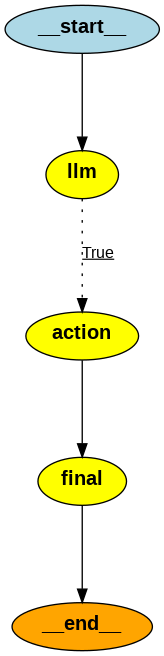

In [16]:
from IPython.display import Image

Image(abot.graph.get_graph().draw_png())

**Input prompt and calling the agent**

In [9]:
messages = [HumanMessage(content="Check for fires in California with brightness greater than 300 and confidence more than 80")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'get_fire_risk_map', 'args': {'place': 'California', 'opencage_key': 'OPENCAGE_KEY', 'firms_key': 'FIRMS_KEY', 'min_brightness': 300, 'min_confidence': 80}, 'id': '9aNwh2v2p', 'type': 'tool_call'}


**Printing each message**

In [10]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

Check for fires in California with brightness greater than 300 and confidence more than 80
================================== Ai Message ==================================
Tool Calls:
  get_fire_risk_map (9aNwh2v2p)
 Call ID: 9aNwh2v2p
  Args:
    place: California
    opencage_key: OPENCAGE_KEY
    firms_key: FIRMS_KEY
    min_brightness: 300
    min_confidence: 80
================================= Tool Message =================================
Name: get_fire_risk_map

<div style="width:100%;"><div style="position:relative;width:100%;height:0;padding-bottom:60%;"><span style="color:#565656">Make this Notebook Trusted to load map: File -> Trust Notebook</span><iframe srcdoc="&lt;!DOCTYPE html&gt;
&lt;html&gt;
&lt;head&gt;
    
    &lt;meta http-equiv=&quot;content-type&quot; content=&quot;text/html; charset=UTF-8&quot; /&gt;
    
        &lt;script&gt;
            L_NO_TOUCH = false;
            L_DISABLE

**Saving the HTML map**

In [11]:
html_map = result['messages'][-1].content

**HTML map was succesfully generated by agent**

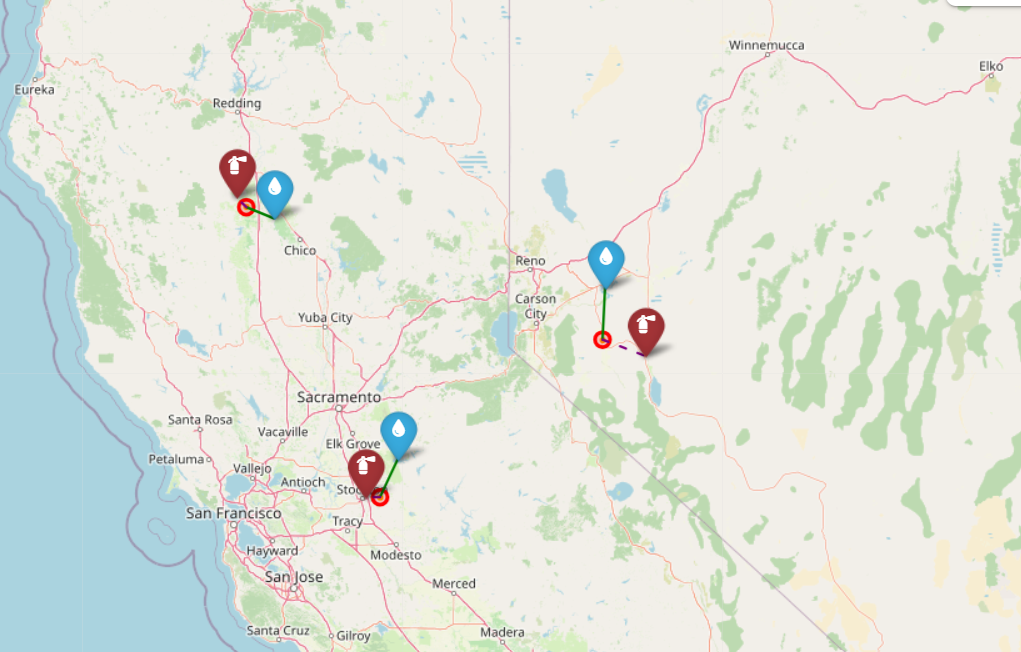

In [13]:
from PIL import Image
import IPython.display as display

img = Image.open('/content/firelink_map.png')  # Replace with your image path
display.display(img)

The HTML depicts the firespots in the california region with each mapped to nearest fire station and water source

**Conclusion**

FireLink demonstrates how AI agents can integrate live geospatial data to provide situational awareness in wildfire-prone regions.
By linking fire detections to the nearest water bodies and fire stations, the system offers an interactive and intuitive visualization layer for decision support. FireLink showcases the potential of combining satellite intelligence, open mapping infrastructure, and natural language interfaces to deliver real-time, actionable insights.